In [2]:
import pandas as pd

df = pd.read_csv("data/Delhi-Metro-Network.csv")

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:\n", df.dtypes)
df.head()

Shape: (285, 8)

Columns: ['Station ID', 'Station Name', 'Distance from Start (km)', 'Line', 'Opening Date', 'Station Layout', 'Latitude', 'Longitude']

Data types:
 Station ID                    int64
Station Name                 object
Distance from Start (km)    float64
Line                         object
Opening Date                 object
Station Layout               object
Latitude                    float64
Longitude                   float64
dtype: object


,Station ID,Station Name,Distance from Start (km),Line,Opening Date,Station Layout,Latitude,Longitude
0,1,Jhil Mil,10.3,Red line,2008-04-06,Elevated,28.675790,77.312390
1,2,Welcome [Conn: Red],46.8,Pink line,2018-10-31,Elevated,28.671800,77.277560
2,3,DLF Phase 3,10.0,Rapid Metro,2013-11-14,Elevated,28.493600,77.093500
3,4,Okhla NSIC,23.8,Magenta line,2017-12-25,Elevated,28.554483,77.264849
4,5,Dwarka Mor,10.2,Blue line,2005-12-30,Elevated,28.619320,77.033260


In [3]:
# --- Missing values ---
print("Missing values per column:\n", df.isnull().sum())

# --- Duplicate rows ---
print("\nDuplicate rows:", df.duplicated().sum())

# --- Duplicate station names (same station listed twice?) ---
print("Duplicate station names:", df["Station Name"].duplicated().sum())

# --- Quick stats on numeric columns ---
df.describe()

Missing values per column:
 Station ID                  0
Station Name                0
Distance from Start (km)    0
Line                        0
Opening Date                0
Station Layout              0
Latitude                    0
Longitude                   0
dtype: int64

Duplicate rows: 0
Duplicate station names: 2


,Station ID,Distance from Start (km),Latitude,Longitude
count,285.000000,285.000000,285.000000,285.000000
mean,143.000000,19.218947,28.595428,77.029315
std,82.416625,14.002862,0.091316,2.875400
min,1.000000,0.000000,27.920862,28.698807
25%,72.000000,7.300000,28.545828,77.107130
50%,143.000000,17.400000,28.613453,77.207220
75%,214.000000,28.800000,28.666360,77.281165
max,285.000000,52.700000,28.878965,77.554479


In [4]:
# Make a copy to keep the raw data untouched
df_clean = df.copy()

# Strip whitespace and standardize text columns
df_clean["Station Name"] = df_clean["Station Name"].str.strip()
df_clean["Line"] = df_clean["Line"].str.strip()
df_clean["Station Layout"] = df_clean["Station Layout"].str.strip()

# Convert Opening Date to proper datetime
df_clean["Opening Date"] = pd.to_datetime(df_clean["Opening Date"], errors="coerce")

# Check how many dates failed to parse (became NaT)
print("Unparsed dates:", df_clean["Opening Date"].isnull().sum())

# Drop exact duplicate rows, if any
df_clean = df_clean.drop_duplicates()

# Sanity check on coordinates (Delhi lies roughly 28.4–28.9 lat, 76.8–77.4 long)
invalid_coords = df_clean[
    (~df_clean["Latitude"].between(28.0, 29.5)) |
    (~df_clean["Longitude"].between(76.5, 77.7))
]
print("Rows with suspicious coordinates:", len(invalid_coords))
invalid_coords

Unparsed dates: 0
Rows with suspicious coordinates: 2


,Station ID,Station Name,Distance from Start (km),Line,Opening Date,Station Layout,Latitude,Longitude
118,119,Lal Quila,1.5,Voilet line,2017-05-28,Underground,27.920862,77.528502
176,177,Shyam park,4.5,Red line,2019-08-03,Elevated,28.698807,28.698807


In [5]:
# Correct known data-entry errors, verified against DMRC/official station data
df_clean.loc[df_clean["Station Name"] == "Lal Quila", "Latitude"] = 28.6576
df_clean.loc[df_clean["Station Name"] == "Lal Quila", "Longitude"] = 77.2366

df_clean.loc[df_clean["Station Name"] == "Shyam park", "Latitude"] = 28.6782
df_clean.loc[df_clean["Station Name"] == "Shyam park", "Longitude"] = 77.3709

# Re-check coordinate sanity after fix
invalid_coords_after = df_clean[
    (~df_clean["Latitude"].between(28.0, 29.5)) |
    (~df_clean["Longitude"].between(76.5, 77.7))
]
print("Remaining suspicious coordinates:", len(invalid_coords_after))

Remaining suspicious coordinates: 0


In [6]:
dupes = df_clean[df_clean.duplicated(subset=["Station Name"], keep=False)]
dupes.sort_values("Station Name")

,Station ID,Station Name,Distance from Start (km),Line,Opening Date,Station Layout,Latitude,Longitude
120,121,Ashok Park Main,1.4,Green line,2010-02-04,Elevated,28.67153,77.15527
196,197,Ashok Park Main,0.0,Green line branch,2010-02-04,Elevated,28.67292,77.14420
115,116,Yamuna Bank,0.0,Blue line branch,2009-10-05,At-Grade,28.62331,77.26792
274,275,Yamuna Bank,35.2,Blue line,2009-10-05,At-Grade,28.62331,77.26792


C:\Users\soham parab\AppData\Local\Temp\ipykernel_9792\3488220880.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=line_counts.values, y=line_counts.index, palette="viridis")


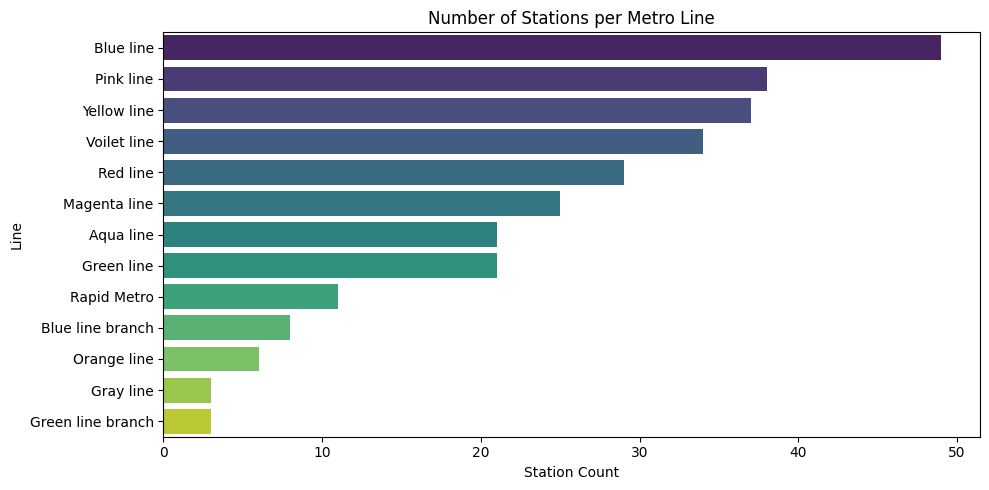

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
line_counts = df_clean["Line"].value_counts()
sns.barplot(x=line_counts.values, y=line_counts.index, palette="viridis")
plt.title("Number of Stations per Metro Line")
plt.xlabel("Station Count")
plt.ylabel("Line")
plt.tight_layout()
plt.show()

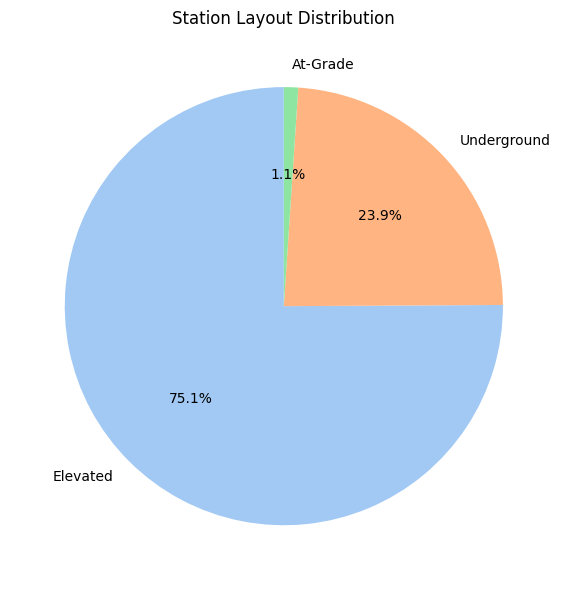

In [8]:
plt.figure(figsize=(6, 6))
df_clean["Station Layout"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel"))
plt.title("Station Layout Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

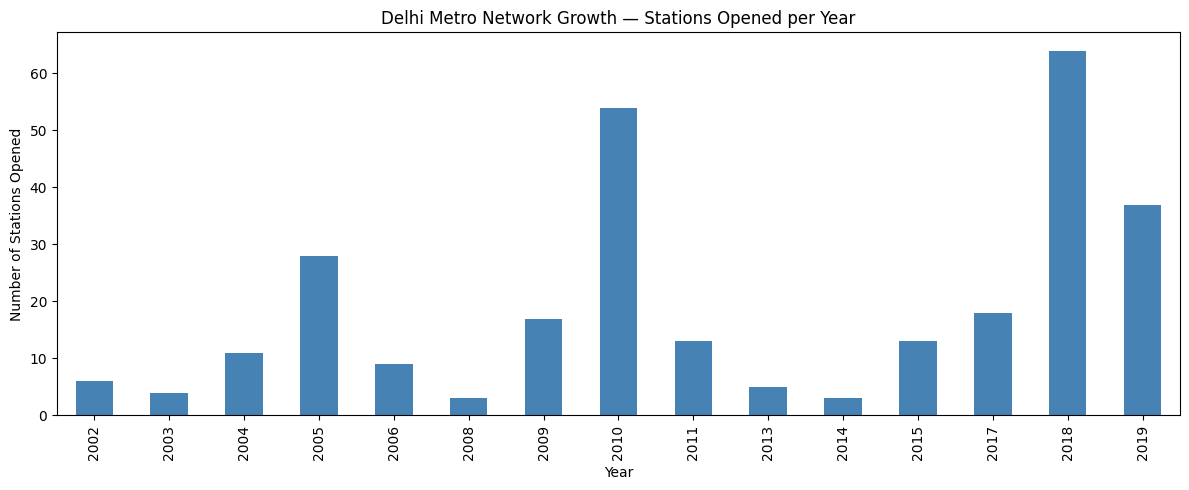

In [9]:
df_clean["Opening Year"] = df_clean["Opening Date"].dt.year

plt.figure(figsize=(12, 5))
df_clean.groupby("Opening Year").size().plot(kind="bar", color="steelblue")
plt.title("Delhi Metro Network Growth \u2014 Stations Opened per Year")
plt.xlabel("Year")
plt.ylabel("Number of Stations Opened")
plt.tight_layout()
plt.show()

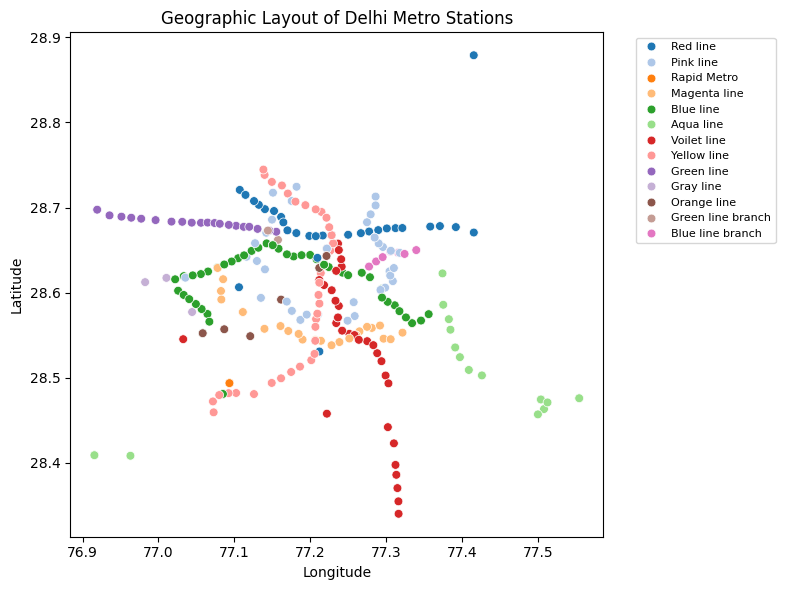

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_clean, x="Longitude", y="Latitude", hue="Line", s=40, palette="tab20")
plt.title("Geographic Layout of Delhi Metro Stations")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [12]:
# Investigate the outlier station (top-right of scatter plot)
outlier = df_clean[df_clean["Latitude"] > 28.85]
print(outlier[["Station Name", "Line", "Latitude", "Longitude"]])

# Fix the "Voilet line" typo
df_clean["Line"] = df_clean["Line"].replace("Voilet line", "Violet line")

# Confirm the fix
print("\nUnique line names after fix:\n", sorted(df_clean["Line"].unique()))

     Station Name      Line   Latitude  Longitude
221  Hindon River  Red line  28.878965  77.415483

Unique line names after fix:
 ['Aqua line', 'Blue line', 'Blue line branch', 'Gray line', 'Green line', 'Green line branch', 'Magenta line', 'Orange line', 'Pink line', 'Rapid Metro', 'Red line', 'Violet line', 'Yellow line']


In [13]:
df_clean.to_csv("data/Delhi-Metro-Network-Cleaned.csv", index=False)
print("Saved cleaned dataset:", df_clean.shape)

Saved cleaned dataset: (285, 9)
